Mental Health in the Workplace 

Introduction 

Employee mental well-being has emerged as one of the most critical factors influencing productivity, job satisfaction, and organizational growth. Companies across the globe are increasingly recognizing that workplace stress, burnout, lack of support systems, and excessive workload directly impact the physical and psychological health of employees. To understand these issues in depth, analyzing real workforce data becomes essential.

This Exploratory Data Analysis (EDA) project focuses on a comprehensive Workplace Mental Health Survey Dataset that contains insights about employees from various countries, departments, job roles, and work cultures. The dataset includes key attributes related to:

👥 Demographics (Age, Gender, Country, Job Role, Department)

🕒 Work Patterns (Work Hours, Years at Company, Remote Work Status, Commute Time)

🩺 Mental Health Indicators (Burnout Level, Mental Health Support Availability, Therapy Access, Burnout Risk)

💼 Workplace Satisfaction (Manager Support Score, Work-Life Balance, Career Growth, Salary Range)

The objective of this EDA is to identify patterns and relationships between workplace conditions and mental health outcomes.

Import Libaries and Data

In [1]:
# import libaries and data set:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(r"C:\Users\NIVINA\Downloads\mental_health_workplace_survey.csv")



View the first row  Data :

In [2]:
df.head()

,EmployeeID,Age,Gender,Country,JobRole,Department,YearsAtCompany,WorkHoursPerWeek,RemoteWork,BurnoutLevel,...,CommuteTime,HasMentalHealthSupport,ManagerSupportScore,HasTherapyAccess,MentalHealthDaysOff,SalaryRange,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
0,1001,50,Male,UK,Sales Associate,HR,14,47,No,3.37,...,117,No,3.15,Yes,8,40K-60K,8.82,6,9.20,0
1,1002,36,Male,Germany,Software Engineer,IT,1,59,Hybrid,7.39,...,8,Yes,4.40,Yes,4,80K-100K,2.80,45,8.46,1
2,1003,29,Non-binary,India,IT Admin,IT,13,59,Hybrid,7.10,...,75,No,3.63,No,6,80K-100K,7.28,7,7.96,1
3,1004,42,Male,Australia,HR Specialist,IT,15,31,Yes,4.18,...,43,Yes,4.50,Yes,9,60K-80K,1.31,11,8.90,0
4,1005,40,Male,Brazil,Customer Support,Support,6,34,Yes,8.28,...,58,Yes,5.51,Yes,6,<40K,1.17,18,8.88,1


View the last row  Data :

In [3]:
df.tail()

,EmployeeID,Age,Gender,Country,JobRole,Department,YearsAtCompany,WorkHoursPerWeek,RemoteWork,BurnoutLevel,...,CommuteTime,HasMentalHealthSupport,ManagerSupportScore,HasTherapyAccess,MentalHealthDaysOff,SalaryRange,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
2995,3996,28,Female,Brazil,Marketing Manager,Sales,18,46,No,2.86,...,4,Yes,6.97,No,1,80K-100K,7.71,21,7.70,0
2996,3997,24,Male,Brazil,Customer Support,Marketing,14,31,No,2.43,...,1,Yes,5.58,Yes,0,60K-80K,3.76,2,2.59,0
2997,3998,22,Female,Canada,Marketing Manager,Marketing,0,38,No,6.87,...,25,No,3.81,No,0,40K-60K,3.03,2,6.95,0
2998,3999,57,Non-binary,Australia,Data Scientist,HR,2,41,No,3.62,...,24,No,9.72,No,3,100K+,6.02,37,9.06,0
2999,4000,46,Non-binary,India,Software Engineer,IT,17,48,No,9.77,...,49,No,8.21,No,7,60K-80K,7.89,37,1.09,1


Separate numerical and categorical values :

In [4]:
num= df.select_dtypes(include=['int64','float'])   # all numeric columns
cat = df.select_dtypes(include=['object']) 
print("Numerical values are:",num)
print("Categorical values are:",cat)

Numerical values are:       EmployeeID  Age  YearsAtCompany  WorkHoursPerWeek  BurnoutLevel  \
0           1001   50              14                47          3.37   
1           1002   36               1                59          7.39   
2           1003   29              13                59          7.10   
3           1004   42              15                31          4.18   
4           1005   40               6                34          8.28   
...          ...  ...             ...               ...           ...   
2995        3996   28              18                46          2.86   
2996        3997   24              14                31          2.43   
2997        3998   22               0                38          6.87   
2998        3999   57               2                41          3.62   
2999        4000   46              17                48          9.77   

      JobSatisfaction  StressLevel  ProductivityScore  SleepHours  \
0                5.06         9.

Data cleaning

Check for missing values in each column :

In [5]:
df.isnull().sum()

EmployeeID                0
Age                       0
Gender                    0
Country                   0
JobRole                   0
Department                0
YearsAtCompany            0
WorkHoursPerWeek          0
RemoteWork                0
BurnoutLevel              0
JobSatisfaction           0
StressLevel               0
ProductivityScore         0
SleepHours                0
PhysicalActivityHrs       0
CommuteTime               0
HasMentalHealthSupport    0
ManagerSupportScore       0
HasTherapyAccess          0
MentalHealthDaysOff       0
SalaryRange               0
WorkLifeBalanceScore      0
TeamSize                  0
CareerGrowthScore         0
BurnoutRisk               0
dtype: int64

Checking Duplicate rows in each column :

In [6]:
df.duplicated().sum()

0

Data Understanding

 Get a summary of the DataFrame, including data types and non-null values

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   EmployeeID              3000 non-null   int64  
 1   Age                     3000 non-null   int64  
 2   Gender                  3000 non-null   object 
 3   Country                 3000 non-null   object 
 4   JobRole                 3000 non-null   object 
 5   Department              3000 non-null   object 
 6   YearsAtCompany          3000 non-null   int64  
 7   WorkHoursPerWeek        3000 non-null   int64  
 8   RemoteWork              3000 non-null   object 
 9   BurnoutLevel            3000 non-null   float64
 10  JobSatisfaction         3000 non-null   float64
 11  StressLevel             3000 non-null   float64
 12  ProductivityScore       3000 non-null   float64
 13  SleepHours              3000 non-null   float64
 14  PhysicalActivityHrs     3000 non-null   

Get Descriptive statistics for numerical columns :

In [8]:
df.describe()

,EmployeeID,Age,YearsAtCompany,WorkHoursPerWeek,BurnoutLevel,JobSatisfaction,StressLevel,ProductivityScore,SleepHours,PhysicalActivityHrs,CommuteTime,ManagerSupportScore,MentalHealthDaysOff,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.00000,3000.00000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000
mean,2500.500000,40.805667,10.099333,44.504000,5.509137,5.43750,5.51535,5.51956,6.539000,5.030400,59.227000,5.44254,4.544667,5.450950,25.20100,5.520680,0.326667
std,866.169729,11.011705,6.035032,8.491526,2.574072,2.59443,2.60361,2.60761,1.441876,2.861026,34.809779,2.59740,2.854129,2.602379,14.08645,2.566861,0.469072
min,1001.000000,22.000000,0.000000,30.000000,1.000000,1.00000,1.00000,1.00000,4.000000,0.000000,0.000000,1.00000,0.000000,1.000000,1.00000,1.000000,0.000000
25%,1750.750000,31.000000,5.000000,37.000000,3.300000,3.18000,3.26000,3.28000,5.300000,2.600000,29.000000,3.16000,2.000000,3.160000,13.00000,3.300000,0.000000
50%,2500.500000,41.000000,10.000000,45.000000,5.480000,5.43000,5.49500,5.49000,6.600000,5.000000,59.000000,5.44000,5.000000,5.425000,25.00000,5.580000,0.000000
75%,3250.250000,50.000000,15.000000,52.000000,7.640000,7.68000,7.82250,7.80250,7.800000,7.500000,90.000000,7.69000,7.000000,7.730000,37.00000,7.642500,1.000000
max,4000.000000,59.000000,20.000000,59.000000,10.000000,10.00000,10.00000,10.00000,9.000000,10.000000,119.000000,9.99000,9.000000,10.000000,49.00000,9.990000,1.000000


1.Count the  Department  columns ?

In [9]:

count_Departments=df["Department"].count()
print(df["Department"])

0              HR
1              IT
2              IT
3              IT
4         Support
          ...    
2995        Sales
2996    Marketing
2997    Marketing
2998           HR
2999           IT
Name: Department, Length: 3000, dtype: object


2.What is the highest data of each column from the whole dataset?

In [10]:

highest=df.max()
print(highest)

EmployeeID                             4000
Age                                      59
Gender                    Prefer not to say
Country                                 USA
JobRole                   Software Engineer
Department                          Support
YearsAtCompany                           20
WorkHoursPerWeek                         59
RemoteWork                              Yes
BurnoutLevel                           10.0
JobSatisfaction                        10.0
StressLevel                            10.0
ProductivityScore                      10.0
SleepHours                              9.0
PhysicalActivityHrs                    10.0
CommuteTime                             119
HasMentalHealthSupport                  Yes
ManagerSupportScore                    9.99
HasTherapyAccess                        Yes
MentalHealthDaysOff                       9
SalaryRange                            <40K
WorkLifeBalanceScore                   10.0
TeamSize                        

3.which Department have WorkLifeBalance ?

In [11]:

pending_count = (df.groupby('Department')['WorkLifeBalanceScore'].sum().sort_values(ascending=False))

print("workLifeBalance count by department:")
print(pending_count)

top_pending_dept = pending_count.idxmax()
print("Department with the highest workLifeBalance :", top_pending_dept)


workLifeBalance count by department:
Department
Sales          2974.30
Marketing      2829.22
HR             2804.15
IT             2622.32
Engineering    2604.22
Support        2518.64
Name: WorkLifeBalanceScore, dtype: float64
Department with the highest workLifeBalance : Sales


4.Count How many Employees in each Department have TherapyAccess ?

In [12]:

therapy_count = (df[df['HasTherapyAccess'] == 'Yes'].groupby('Department').size().sort_values(ascending=False))

print("Therapy access count by department:")
print(therapy_count)


Therapy access count by department:
Department
Sales          270
Marketing      250
Engineering    249
HR             246
IT             238
Support        236
dtype: int64


5.which Departments takes Burnout riks ?

In [13]:

df.columns = df.columns.str.strip()   # clean column names
burnout_dept_gender = (df.groupby(['Department', 'Gender'])['BurnoutRisk'].sum().sort_values(ascending=False))

top_group = burnout_dept_gender.idxmax()
print(" Department Gender group with highest burnout:", top_group)


 Department Gender group with highest burnout: ('HR', 'Non-binary')


6.Which work environments show higher burnout risk?

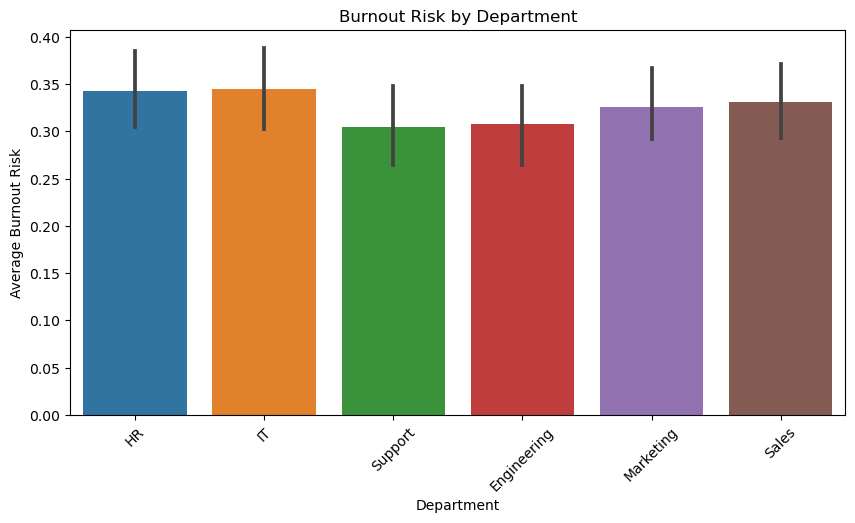

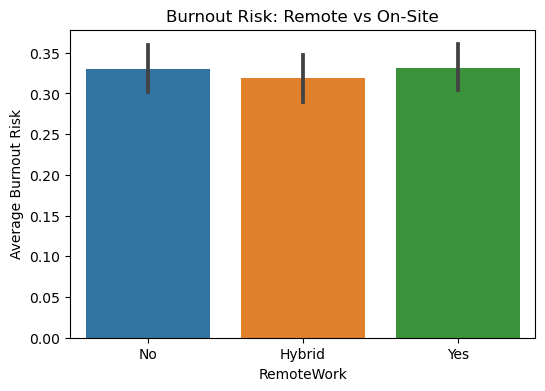

In [14]:
#Detect stress/burnout column
if "BurnoutRisk" in df.columns:
    burnout_col = "BurnoutRisk"
else:
    burnout_col = "StressLevel"


# 1) Burnout by Department

plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Department", y=burnout_col)
plt.title("Burnout Risk by Department")
plt.xticks(rotation=45)
plt.ylabel("Average Burnout Risk")
plt.show()

# 2) Burnout by Remote Work Status

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="RemoteWork", y=burnout_col)
plt.title("Burnout Risk: Remote vs On-Site")
plt.ylabel("Average Burnout Risk")
plt.show()




7.Does Remote Work Reduce Workplace Stress?

RemoteWork
Hybrid    0.318982
No        0.330303
Yes       0.330972
Name: BurnoutRisk, dtype: float64


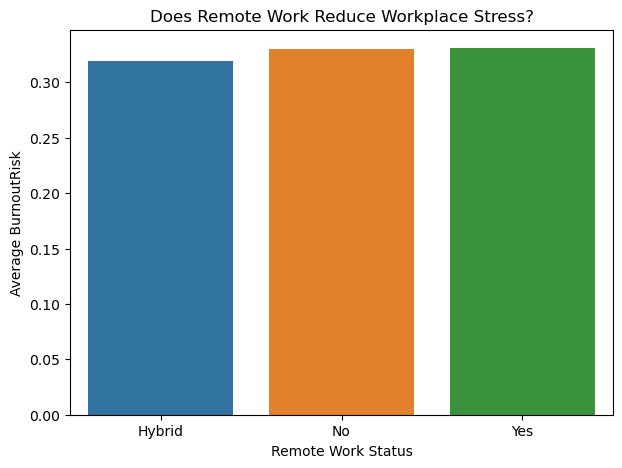

In [15]:
# Find the burnout/stress column
if "BurnoutRisk" in df.columns:
    stress_col = "BurnoutRisk"
else:
    stress_col = "StressLevel"

# Group by Remote Work and find average stress/burnout
remote_stress = df.groupby('RemoteWork')[stress_col].mean().sort_values()

print(remote_stress)

# Visualization
plt.figure(figsize=(7,5))
sns.barplot(x=remote_stress.index, y=remote_stress.values)
plt.title("Does Remote Work Reduce Workplace Stress?")
plt.xlabel("Remote Work Status")
plt.ylabel(f"Average {stress_col}")
plt.show()

8.which Department have more JobSatisfaction ?

In [16]:

satisfied_roles = (df.groupby('JobSatisfaction')['JobRole'].sum().sort_values(ascending=False))
top_pending_dept = pending_count.idxmax()
print("Job role with highest satisfaction :", top_pending_dept)



Job role with highest satisfaction : Sales


 9.Check the Correlation of  working hours and commute times linked to mental health issues?

In [17]:

# Detect stress/burnout column automatically
if "BurnoutRisk" in df.columns:
    stress_col = "BurnoutRisk"
else:
    stress_col = "StressLevel"

print("Using stress indicator:", stress_col)

# 3) Correlation Check

corr1 = df[['WorkHoursPerWeek', stress_col]].corr().iloc[0,1]
corr2 = df[['CommuteTime', stress_col]].corr().iloc[0,1]

print("\nCorrelation with Mental Health Issues:")
print(f" Work Hours vs {stress_col} = {corr1:.2f}")
print(f" Commute Time vs {stress_col} = {corr2:.2f}")


Using stress indicator: BurnoutRisk

Correlation with Mental Health Issues:
 Work Hours vs BurnoutRisk = -0.02
 Commute Time vs BurnoutRisk = 0.03


10.Filter which country is use  remotworks ?

Country
India        170
Brazil       160
Germany      138
Australia    136
UK           133
Canada       127
USA          124
dtype: int64
Country using the most remote work: India


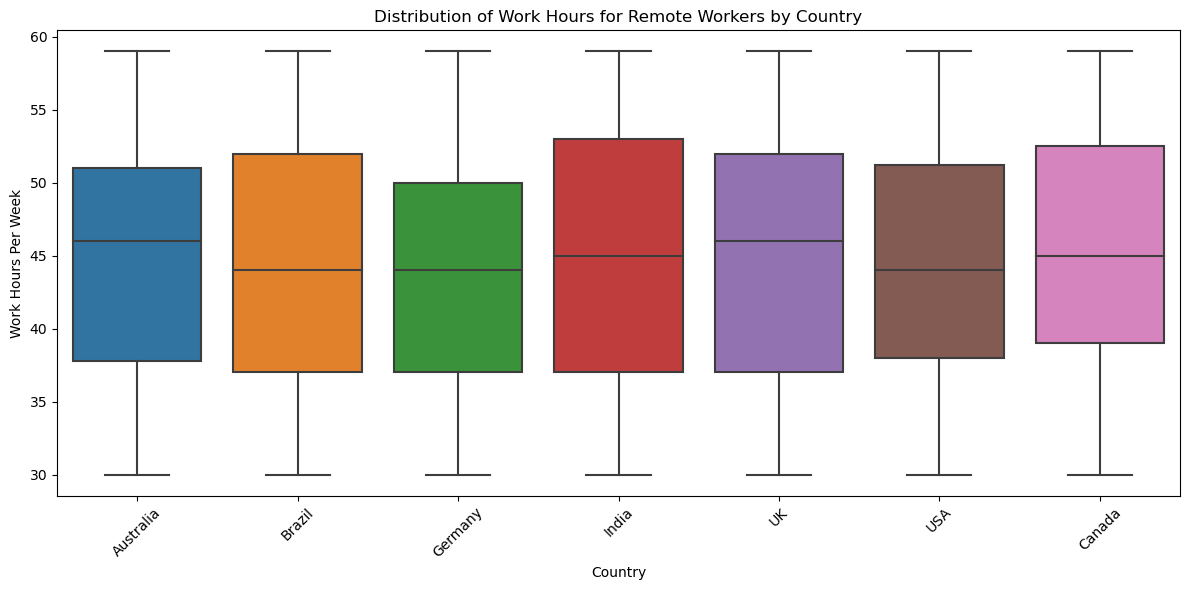

In [18]:

remote_country = (df[df['RemoteWork'] == 'Yes'].groupby('Country').size().sort_values(ascending=False))
print(remote_country)
top_country = remote_country.idxmax()
print("Country using the most remote work:", top_country)

plt.figure(figsize=(12,6))
sns.boxplot(x='Country', y='WorkHoursPerWeek', data=df[df['RemoteWork'] == 'Yes'])

plt.title("Distribution of Work Hours for Remote Workers by Country")
plt.xlabel("Country")
plt.ylabel("Work Hours Per Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



11.Calculate percentage of workers with mental health support for each country ?

In [19]:

country_percent = (
    df.groupby("Country")["HasMentalHealthSupport"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)
# Display the result
print("Percentage of job workers having mental health support in each country:\n")
print(country_percent)

Percentage of job workers having mental health support in each country:

Country
USA          50.980392
Canada       50.921659
Germany      49.753695
India        48.706897
Brazil       48.081264
UK           47.540984
Australia    46.889952
Name: HasMentalHealthSupport, dtype: float64


12.How much Employee sleeps on commute time ? 

In [20]:

sleep_time=df.loc[df["EmployeeID"].idxmax(),'CommuteTime'] 
print("how much employee sleeps on commute time:",sleep_time)

how much employee sleeps on commute time: 49


13.which Employees of Departments are Facing  more Stress ?

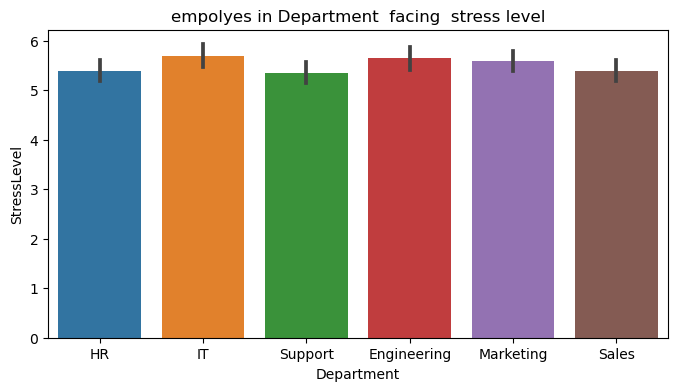

In [21]:


plt.figure(figsize=(8, 4))
sns.barplot(x='Department', y='StressLevel', data=df)
plt.title('empolyes in Department  facing  stress level')
plt.show()



14.Count the Working Hours in Peer Week :

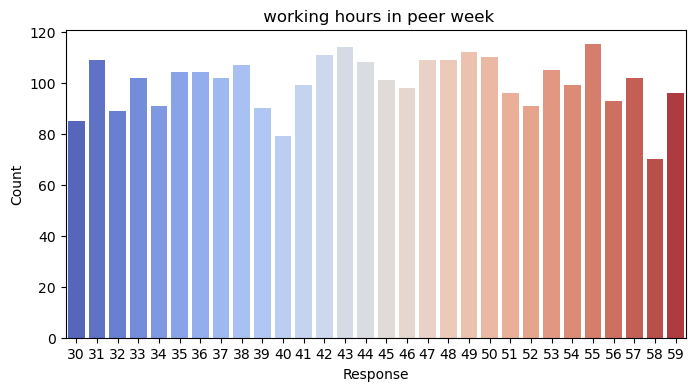

In [22]:

plt.figure(figsize=(8,4))
sns.countplot(x='WorkHoursPerWeek', data=df, palette='coolwarm')
plt.title(' working hours in peer week')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()




        EmployeeID          Age  YearsAtCompany  WorkHoursPerWeek  \
count  3000.000000  3000.000000     3000.000000       3000.000000   
mean   2500.500000    40.805667       10.099333         44.504000   
std     866.169729    11.011705        6.035032          8.491526   
min    1001.000000    22.000000        0.000000         30.000000   
25%    1750.750000    31.000000        5.000000         37.000000   
50%    2500.500000    41.000000       10.000000         45.000000   
75%    3250.250000    50.000000       15.000000         52.000000   
max    4000.000000    59.000000       20.000000         59.000000   

       BurnoutLevel  JobSatisfaction  StressLevel  ProductivityScore  \
count   3000.000000       3000.00000   3000.00000         3000.00000   
mean       5.509137          5.43750      5.51535            5.51956   
std        2.574072          2.59443      2.60361            2.60761   
min        1.000000          1.00000      1.00000            1.00000   
25%        3.30000

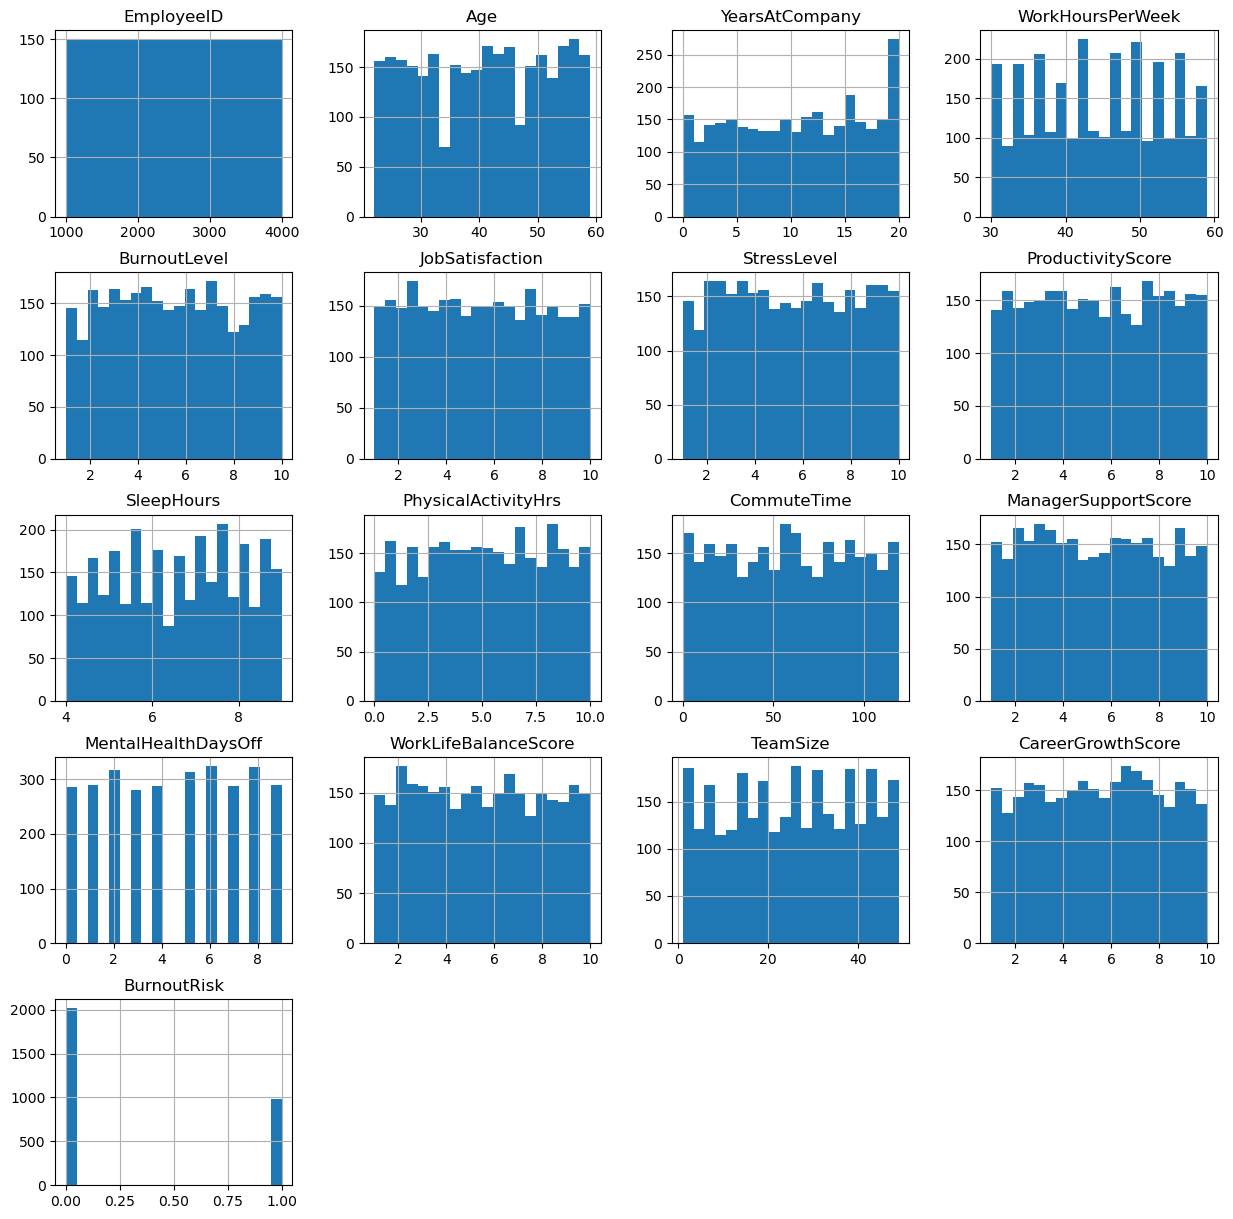

In [30]:
#univarient analysis of numerical data
num = df.select_dtypes(include=['int64', 'float64'])
print(num.describe())

# Histograms 
num.hist(bins=20, figsize=(15,15))
plt.show()



Outlier Detection

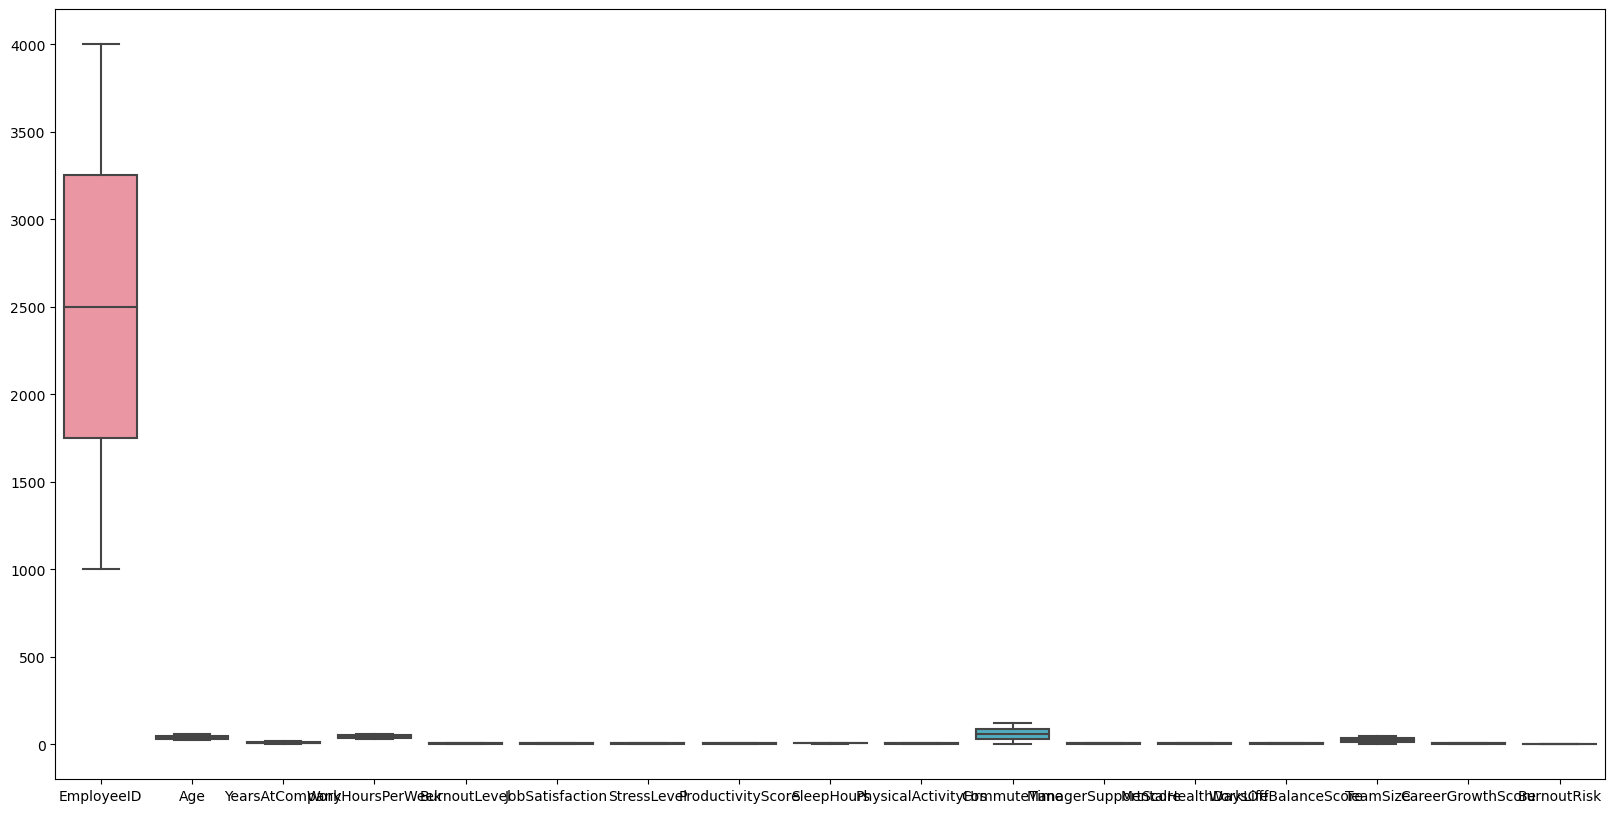

In [24]:
# Boxplots 
plt.figure(figsize=(20,10))
sns.boxplot(data=num)
plt.show()

In [25]:

# univarient analysis of categorical data


cat = df.select_dtypes(include=['object'])
print(cat.describe())

# frequency count
for c in cat:
    print(f"\nValue counts for {c}:")
    print(cat[c].value_counts())

            Gender Country         JobRole Department RemoteWork  \
count         3000    3000            3000       3000       3000   
unique           4       7               8          6          3   
top     Non-binary   India  Data Scientist         HR     Hybrid   
freq           757     464             411        525       1022   

       HasMentalHealthSupport HasTherapyAccess SalaryRange  
count                    3000             3000        3000  
unique                      2                2           5  
top                        No               No       100K+  
freq                     1531             1511         640  

Value counts for Gender:
Non-binary           757
Prefer not to say    757
Male                 752
Female               734
Name: Gender, dtype: int64

Value counts for Country:
India        464
Brazil       443
Canada       434
UK           427
Australia    418
USA          408
Germany      406
Name: Country, dtype: int64

Value counts for JobRole:


Numerical values are: Index(['EmployeeID', 'Age', 'YearsAtCompany', 'WorkHoursPerWeek',
       'BurnoutLevel', 'JobSatisfaction', 'StressLevel', 'ProductivityScore',
       'SleepHours', 'PhysicalActivityHrs', 'CommuteTime',
       'ManagerSupportScore', 'MentalHealthDaysOff', 'WorkLifeBalanceScore',
       'TeamSize', 'CareerGrowthScore', 'BurnoutRisk'],
      dtype='object')
Categorical values are: Index(['Gender', 'Country', 'JobRole', 'Department', 'RemoteWork',
       'HasMentalHealthSupport', 'HasTherapyAccess', 'SalaryRange'],
      dtype='object')


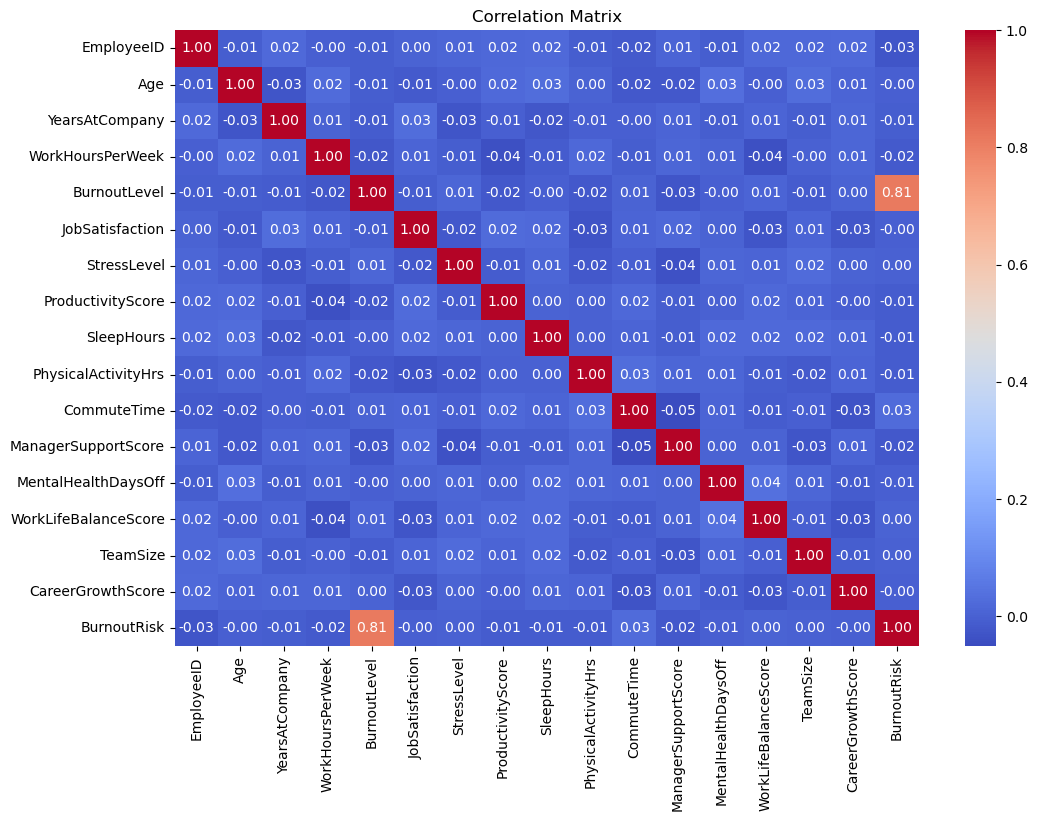

In [26]:
df.duplicated().sum()
numeric_columns= df.select_dtypes(include=['int64', 'float64']) .columns  # all numeric columns
cat = df.select_dtypes(include=['object']) .columns
print("Numerical values are:",numeric_columns)
print("Categorical values are:",cat)  

# numerical vs numerical analysis

corr_matrix = df[numeric_columns].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [27]:
df.duplicated().sum()
numeric_columns= df.select_dtypes(include=['int64', 'float64']) .columns  # all numeric columns
cat = df.select_dtypes(include=['object']) .columns
print("Numerical values are:",numeric_columns)
print("Categorical values are:",cat)  

Numerical values are: Index(['EmployeeID', 'Age', 'YearsAtCompany', 'WorkHoursPerWeek',
       'BurnoutLevel', 'JobSatisfaction', 'StressLevel', 'ProductivityScore',
       'SleepHours', 'PhysicalActivityHrs', 'CommuteTime',
       'ManagerSupportScore', 'MentalHealthDaysOff', 'WorkLifeBalanceScore',
       'TeamSize', 'CareerGrowthScore', 'BurnoutRisk'],
      dtype='object')
Categorical values are: Index(['Gender', 'Country', 'JobRole', 'Department', 'RemoteWork',
       'HasMentalHealthSupport', 'HasTherapyAccess', 'SalaryRange'],
      dtype='object')


Histogram of each columns :

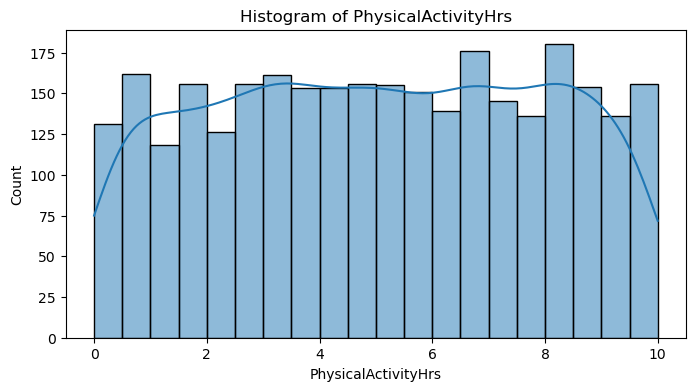

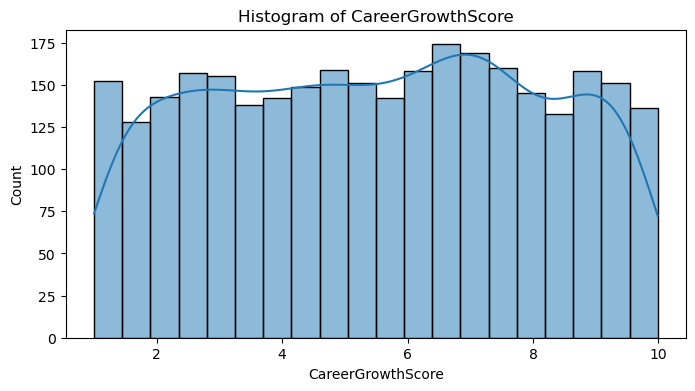

In [28]:
selected_cols = ['PhysicalActivityHrs', 'CareerGrowthScore']  


plt.figure(figsize=(8, 4))
sns.histplot(df['PhysicalActivityHrs'], kde=True, bins=20)
plt.title('Histogram of PhysicalActivityHrs')
plt.xlabel('PhysicalActivityHrs')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['CareerGrowthScore'], kde=True, bins=20)
plt.title('Histogram of CareerGrowthScore')
plt.xlabel('CareerGrowthScore')
plt.ylabel('Count')
plt.show()



Trend and pattern analysis: Salary based on Work Hours Per Week

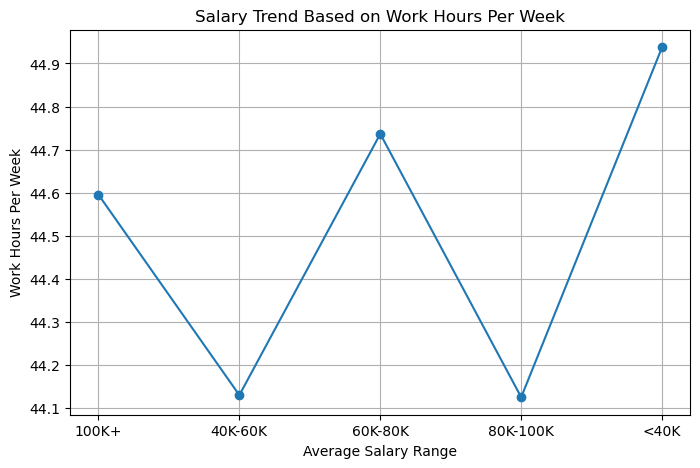

In [29]:


salary_by_hours = df.groupby('SalaryRange')['WorkHoursPerWeek'].mean().sort_index()

plt.figure(figsize=(8,5))
plt.plot(salary_by_hours.index, salary_by_hours.values, marker='o')
plt.title("Salary Trend Based on Work Hours Per Week")
plt.xlabel("Average Salary Range")
plt.ylabel("Work Hours Per Week")
plt.grid(True)
plt.show()


Suggestions & Recommendations

1. Reduce Burnout Through Workload Balancing

If certain departments or genders show higher burnout, HR should:

Reevaluate workload distribution

Increase staffing or automate repetitive tasks

Introduce mandatory break schedules

Provide burnout alert systems using periodic surveys.

2. Improve Work-Life Balance

If employees working longer hours per week earn more but show poor well-being:

Implement flexible work hours

Introduce hybrid or remote working options

Encourage paid time-off usage

Managers should monitor weekly work hours to prevent overwork.

3. Enhance Mental Health Support Programs

If the dataset shows low MentalHealthSupport in some countries or departments:

Provide easy access to therapists or counselors

Promote awareness about mental health resources

Offer anonymous online consultations

Provide stress-management workshops

4. Increase Therapy Access in Low-Access Departments

Departments with low TherapyAccess should:

Receive dedicated mental health sessions

Be offered subsidized therapy programs

Create safe spaces for emotional support

5. Strengthen Manager Support

If ManagerSupportScore is weak in some departments:

Train managers in empathy, communication, and conflict resolution

Introduce monthly check-in meetings

Implement anonymous feedback loops for employees

6. Boost Job Satisfaction

If specific job roles show low JobSatisfaction:

Identify reasons (low salary, poor leadership, high stress)

Introduce career growth paths and recognition programs

Offer skill development and training sessions

7. Address Gender-Based Burnout Gaps

If one gender faces more burnout:

Conduct gender-specific focus groups

Improve inclusiveness and workplace equality

Provide personalized mental health resources

8. Optimize Salary Based on WorkHoursPerWeek Trends

If employees working excessive hours do not receive proportional salary:

Reassess salary structure

Offer overtime compensation

Provide bonuses for high-effort roles

If certain hours correlate with highest productivity, adjust schedules accordingly.

9. Country-Specific Policy Improvements

If some countries have lower mental health support or remote work adoption:

Implement global-standard wellness programs

Encourage cross-country policy learning

Invest in mental health infrastructure in weaker regions

10. Promote Healthy Remote Work Culture

If countries with more remote work show better well-being:

Expand remote work where possible

Provide home-office subsidies

Train employees on remote productivity and ergonomics